In [140]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error
from sklearn.impute import SimpleImputer

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch device: {DEVICE}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

try:
    import lightgbm as lgb
    HAS_LGBM = True
    print("LightGBM available")
except ImportError:
    HAS_LGBM = False
    print("LightGBM NOT found — run: pip install lightgbm")

try:
    import xgboost as xgb
    HAS_XGB = True
    print("XGBoost available")
except ImportError:
    HAS_XGB = False
    print("XGBoost NOT found — run: pip install xgboost")

%matplotlib inline

PyTorch device: cuda
  GPU: NVIDIA GeForce RTX 5080 Laptop GPU
LightGBM available
XGBoost available


In [141]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
NVIDIA GeForce RTX 5080 Laptop GPU


# PR2: Regression — Airbnb Nightly Price Prediction

## 1. Load Data

In [142]:
train_df = pd.read_csv("train.csv")
test_df  = pd.read_csv("test.csv")

print(f"Train shape: {train_df.shape}")
print(f"Test  shape: {test_df.shape}")
print("\nTrain columns:")
print(train_df.dtypes.to_string())
train_df.head(3)

Train shape: (89524, 66)
Test  shape: (22382, 65)

Train columns:
name                                             object
description                                      object
host_name                                        object
host_since                                       object
host_location                                    object
host_about                                       object
host_response_time                               object
host_response_rate                               object
host_acceptance_rate                             object
host_is_superhost                                object
host_neighbourhood                               object
host_listings_count                             float64
host_total_listings_count                       float64
host_verifications                               object
host_has_profile_pic                             object
host_identity_verified                           object
neighbourhood                         

,name,description,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,...,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,reviews,price
0,Beach House one block from Mission Bay w/AC,"Just one block from the bay, this quiet and co...",Kevin,2023-04-22,"San Diego, CA",Born and raised San Diegan! I love this town a...,NaN,NaN,NaN,f,...,1,0,0,2.77,NaN,NaN,NaN,NaN,NaN,200.0
1,MC Manor 2 has air condition for winter and s...,1 bdrm 1 bth Living room area w/ kitchenette.l...,Mehry,2015-05-23,"Los Angeles, CA",I am a piano teacher. Studied music . I have a...,within an hour,100%,100%,t,...,2,0,0,2.41,242.0,25.0,162.0,29970.0,NaN,185.0
2,Stylish Bay Ridge Studio: Experience NYC Living,This cozy studio provides the perfect balance ...,Shlome,2022-07-31,NaN,NaN,within an hour,100%,100%,f,...,56,2,0,3.79,299.0,26.0,255.0,28305.0,NaN,111.0


## 2. Target Distribution & Outlier Handling (Task 5 + Task 1)

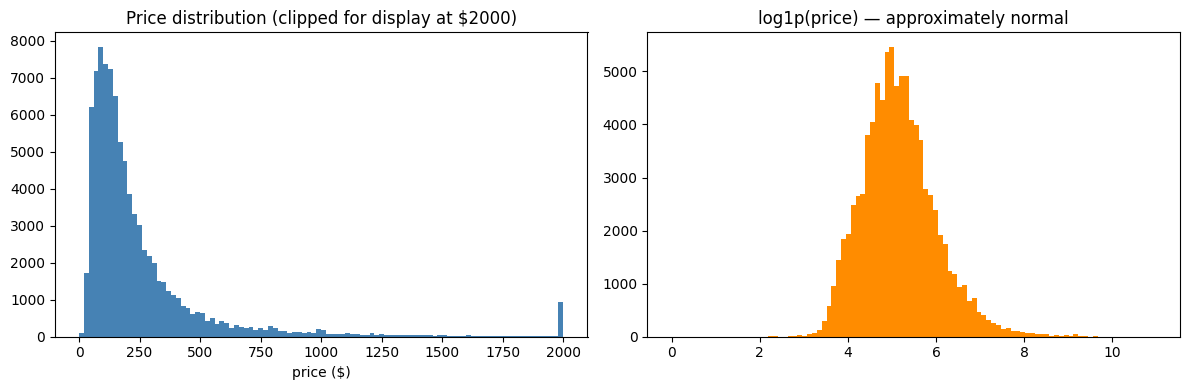

Price stats:
count    89524.000000
mean       281.808051
std        675.106777
min          0.000000
25%         98.000000
50%        161.000000
75%        282.250000
max      59000.000000
Name: price, dtype: float64

log_price stats:
count    89524.000000
mean         5.163839
std          0.848408
min          0.000000
25%          4.595120
50%          5.087596
75%          5.646329
max         10.985310
Name: log_price, dtype: float64


In [143]:
TARGET = "price"

def parse_price(series):
    if series.dtype == object:
        series = series.str.replace(r'[\$,]', '', regex=True).astype(float)
    return series

train_df[TARGET] = parse_price(train_df[TARGET])

# Log-transform the target — this handles skewness without capping.
# Capping was previously hiding errors on high-priced listings from local
# val RMSE, causing a massive gap vs leaderboard RMSE. Do NOT cap.
train_df["log_price"] = np.log1p(train_df[TARGET])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_df[TARGET].dropna().clip(upper=2000), bins=100,
             color='steelblue', edgecolor='none')
axes[0].set_title("Price distribution (clipped for display at $2000)")
axes[0].set_xlabel("price ($)")

axes[1].hist(train_df["log_price"].dropna(), bins=100, color='darkorange', edgecolor='none')
axes[1].set_title("log1p(price) — approximately normal")

plt.tight_layout()
plt.show()

print(f"Price stats:\n{train_df[TARGET].describe()}")
print(f"\nlog_price stats:\n{train_df['log_price'].describe()}")

## 3. Data Cleaning — Missing Values & Type Fixes (Task 1)

In [144]:
def clean_df(df, is_train=True):
    df = df.copy()

    # --- Extract amenities count before dropping the raw text column ---
    if 'amenities' in df.columns:
        df['amenities_count'] = df['amenities'].fillna('').str.count(',') + \
                                df['amenities'].fillna('').str.len().gt(2).astype(int)
        df = df.drop(columns=['amenities'])

    # --- Parse dollar-string columns (require >50% to start with '$') ---
    dollar_cols = [c for c in df.columns if df[c].dtype == object
                   and df[c].dropna().str.startswith('$').mean() > 0.5]
    for c in dollar_cols:
        df[c] = pd.to_numeric(df[c].str.replace(r'[\$,]', '', regex=True), errors='coerce')

    # --- Parse percentage strings ---
    pct_cols = [c for c in df.columns if df[c].dtype == object
                and df[c].dropna().str.endswith('%').mean() > 0.5]
    for c in pct_cols:
        df[c] = pd.to_numeric(df[c].str.replace('%', '', regex=False), errors='coerce') / 100.0

    # --- Boolean-like t/f columns ---
    bool_cols = [c for c in df.columns if df[c].dtype == object
                 and set(df[c].dropna().unique()).issubset({'t', 'f'})]
    for c in bool_cols:
        df[c] = (df[c] == 't').astype(int)

    # --- Drop columns with >60% missing or that are identifiers/text blobs ---
    # NOTE: latitude and longitude are kept — location is a strong price signal
    drop_thresh = 0.60
    missing_frac = df.isnull().mean()
    high_missing = missing_frac[missing_frac > drop_thresh].index.tolist()

    id_like = [c for c in df.columns if c.lower() in
               {'id', 'listing_url', 'scrape_id', 'last_scraped', 'name',
                'summary', 'space', 'description', 'experiences_offered',
                'neighborhood_overview', 'notes', 'transit', 'access',
                'interaction', 'house_rules', 'thumbnail_url', 'medium_url',
                'picture_url', 'xl_picture_url', 'host_url', 'host_name',
                'host_about', 'host_thumbnail_url', 'host_picture_url',
                'host_verifications', 'street', 'city', 'state', 'zipcode',
                'market', 'smart_location', 'country_code', 'country',
                'calendar_updated', 'calendar_last_scraped',
                'first_review', 'last_review',
                'license', 'jurisdiction_names', 'host_id'}]

    to_drop = list(set(high_missing + id_like))
    to_drop = [c for c in to_drop if c in df.columns and c != TARGET]
    df = df.drop(columns=to_drop)
    if is_train:
        print(f"Dropped {len(to_drop)} columns: {sorted(to_drop)}")

    # --- Fill numerical NaNs with median ---
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    for c in num_cols:
        if c not in (TARGET, 'log_price'):
            df[c] = df[c].fillna(df[c].median())

    # --- Fill categorical NaNs with 'missing' ---
    cat_cols = df.select_dtypes(include='object').columns.tolist()
    for c in cat_cols:
        df[c] = df[c].fillna('missing')

    return df, to_drop

train_clean, dropped_cols = clean_df(train_df, is_train=True)

test_df_clean = test_df.copy()
for c in dropped_cols:
    if c in test_df_clean.columns:
        test_df_clean = test_df_clean.drop(columns=[c])
test_df_clean, _ = clean_df(test_df_clean, is_train=False)

print(f"\nTrain clean shape: {train_clean.shape}")
print(f"Test  clean shape: {test_df_clean.shape}")
print(f"\nMissing values remaining:\n{train_clean.isnull().sum()[train_clean.isnull().sum()>0]}")

Dropped 10 columns: ['calendar_updated', 'description', 'first_review', 'host_about', 'host_name', 'host_verifications', 'last_review', 'license', 'name', 'reviews']

Train clean shape: (89524, 57)
Test  clean shape: (22382, 55)

Missing values remaining:
Series([], dtype: int64)


In [ ]:
# geo_grid MUST be created here — before target encoding — so it gets
# target-encoded (mean price per cell) rather than just frequency-encoded.
def add_geo_grid(df):
    if 'latitude' in df.columns and 'longitude' in df.columns:
        df = df.copy()
        df['lat_bin'] = (df['latitude'] // 0.05).fillna(0).astype(int).astype(str)
        df['lon_bin'] = (df['longitude'] // 0.05).fillna(0).astype(int).astype(str)
        df['geo_grid'] = df['lat_bin'] + '_' + df['lon_bin']
        df = df.drop(columns=['lat_bin', 'lon_bin'])
    return df

train_clean   = add_geo_grid(train_clean)
test_df_clean = add_geo_grid(test_df_clean)
print(f"geo_grid unique values — train: {train_clean['geo_grid'].nunique()}  "
      f"test: {test_df_clean['geo_grid'].nunique()}")

## 3b. Target Encoding for High-Cardinality Categoricals

In [145]:
def target_encode_oof(train, test, cols, target='log_price', n_splits=5, smoothing=10):
    """Out-of-fold target encoding with Bayesian smoothing — no leakage."""
    train, test = train.copy(), test.copy()
    global_mean = train[target].mean()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    for col in cols:
        if col not in train.columns:
            continue
        new_col = f'te_{col}'
        train[new_col] = global_mean

        for tr_idx, val_idx in kf.split(train):
            agg = train.iloc[tr_idx].groupby(col)[target].agg(['mean', 'count'])
            smooth = agg['count'] / (agg['count'] + smoothing)
            smoothed = smooth * agg['mean'] + (1 - smooth) * global_mean
            train.loc[train.index[val_idx], new_col] = (
                train.iloc[val_idx][col].map(smoothed).fillna(global_mean).values
            )

        agg = train.groupby(col)[target].agg(['mean', 'count'])
        smooth = agg['count'] / (agg['count'] + smoothing)
        smoothed = smooth * agg['mean'] + (1 - smooth) * global_mean
        test[new_col] = test[col].map(smoothed).fillna(global_mean)

    added = [f'te_{c}' for c in cols if c in train.columns]
    print(f"Target-encoded {len(added)} columns: {added}")
    return train, test

te_candidates = [
    'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'neighbourhood',
    'property_type', 'host_neighbourhood', 'cancellation_policy', 'bed_type',
    'geo_grid',           # geographic grid cells — high-signal location feature
]
te_cols = [c for c in te_candidates if c in train_clean.columns]
train_clean, test_df_clean = target_encode_oof(train_clean, test_df_clean, te_cols)
print(f"Train shape: {train_clean.shape}")

Target-encoded 5 columns: ['te_neighbourhood_cleansed', 'te_neighbourhood_group_cleansed', 'te_neighbourhood', 'te_property_type', 'te_host_neighbourhood']
Train shape: (89524, 62)


## 4. Feature Engineering (Task 1)

In [ ]:
def engineer_features(df):
    df = df.copy()

    # ── Neighbourhood popularity (frequency) ──────────────────────────────────
    if 'neighbourhood_cleansed' in df.columns:
        freq = df['neighbourhood_cleansed'].value_counts(normalize=True)
        df['neighbourhood_popularity'] = df['neighbourhood_cleansed'].map(freq).fillna(0)

    # ── Review score composite ─────────────────────────────────────────────────
    review_score_cols = [c for c in df.columns if c.startswith('review_scores_')]
    if review_score_cols:
        df['review_scores_mean'] = df[review_score_cols].mean(axis=1)

    # ── Host tenure ────────────────────────────────────────────────────────────
    if 'host_since' in df.columns:
        df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
        df['host_tenure_days'] = (pd.Timestamp('2020-01-01') - df['host_since']).dt.days.clip(lower=0)
        df = df.drop(columns=['host_since'])

    # ── Availability ratios ────────────────────────────────────────────────────
    if 'availability_365' in df.columns:
        df['availability_rate'] = df['availability_365'] / 365.0
    if 'availability_30' in df.columns and 'availability_365' in df.columns:
        df['near_term_avail_ratio'] = df['availability_30'] / (df['availability_365'] + 1)

    # ── Interaction features ───────────────────────────────────────────────────
    if 'accommodates' in df.columns:
        if 'bedrooms' in df.columns:
            df['accom_per_bedroom'] = df['accommodates'] / (df['bedrooms'].clip(lower=1))
        if 'bathrooms' in df.columns:
            df['bathroom_per_person'] = df['bathrooms'] / (df['accommodates'].clip(lower=1))
        if 'beds' in df.columns:
            df['accom_per_bed'] = df['accommodates'] / (df['beds'].clip(lower=1))

    # ── Review demand signal ───────────────────────────────────────────────────
    if 'number_of_reviews' in df.columns and 'minimum_nights' in df.columns:
        df['reviews_per_min_night'] = df['number_of_reviews'] / (df['minimum_nights'] + 1)
    if 'review_scores_mean' in df.columns and 'number_of_reviews' in df.columns:
        df['quality_volume'] = df['review_scores_mean'] * np.log1p(df['number_of_reviews'])

    # ── Log-transform skewed numerics ─────────────────────────────────────────
    for c in ['number_of_reviews', 'reviews_per_month', 'host_listings_count',
              'calculated_host_listings_count', 'minimum_nights']:
        if c in df.columns:
            df[f'log_{c}'] = np.log1p(df[c].clip(lower=0))

    return df

train_clean   = engineer_features(train_clean)
test_df_clean = engineer_features(test_df_clean)
print(f"Train shape after feature engineering: {train_clean.shape}")

## 5. Feature Encoding — Categorical → Numeric (Task 2)

In [147]:
def encode_categoricals(train, test, low_card_thresh=20):
    """
    Low-cardinality categoricals  -> one-hot encoding
    High-cardinality categoricals -> frequency encoding (avoids huge sparse matrices)
    """
    train, test = train.copy(), test.copy()

    cat_cols = train.select_dtypes(include='object').columns.tolist()
    # exclude target
    cat_cols = [c for c in cat_cols if c not in (TARGET, 'log_price')]

    ohe_cols  = [c for c in cat_cols if train[c].nunique() <= low_card_thresh]
    freq_cols = [c for c in cat_cols if train[c].nunique() >  low_card_thresh]

    print(f"One-hot encoding ({len(ohe_cols)} cols): {ohe_cols}")
    print(f"Frequency encoding ({len(freq_cols)} cols): {freq_cols}")

    # One-hot
    if ohe_cols:
        train = pd.get_dummies(train, columns=ohe_cols, drop_first=True)
        test  = pd.get_dummies(test,  columns=ohe_cols, drop_first=True)
        # Align — add missing columns with 0
        for c in train.columns:
            if c not in test.columns and c not in (TARGET, 'log_price'):
                test[c] = 0
        # Drop test-only columns
        extra = [c for c in test.columns if c not in train.columns]
        test = test.drop(columns=extra)

    # Frequency encoding
    for c in freq_cols:
        freq_map = train[c].value_counts(normalize=True).to_dict()
        train[c] = train[c].map(freq_map).fillna(0)
        test[c]  = test[c].map(freq_map).fillna(0)

    return train, test

train_enc, test_enc = encode_categoricals(train_clean, test_df_clean)
print(f"\nTrain encoded shape: {train_enc.shape}")
print(f"Test  encoded shape: {test_enc.shape}")

One-hot encoding (4 cols): ['host_response_time', 'neighbourhood', 'neighbourhood_group_cleansed', 'room_type']
Frequency encoding (5 cols): ['host_location', 'host_neighbourhood', 'neighbourhood_cleansed', 'property_type', 'bathrooms_text']

Train encoded shape: (89524, 89)
Test  encoded shape: (22382, 87)


## 6. Train / Val Split + Feature Matrix

In [148]:
# Save test IDs before dropping
TEST_ID_COL = 'id' if 'id' in test_enc.columns else test_enc.columns[0]
test_ids = test_enc[TEST_ID_COL].values if TEST_ID_COL in test_enc.columns else np.arange(len(test_enc))

# Build feature matrix — drop target and id columns
drop_from_X = [c for c in [TARGET, 'log_price', 'id', TEST_ID_COL]
               if c in train_enc.columns]
feature_cols = [c for c in train_enc.columns if c not in drop_from_X]

X_all  = train_enc[feature_cols].values.astype(np.float32)
y_log  = train_enc['log_price'].values          # model in log space
y_raw  = train_enc[TARGET].values

X_test = test_enc[[c for c in feature_cols if c in test_enc.columns]].values.astype(np.float32)

# Align missing test columns
for i, c in enumerate(feature_cols):
    if c not in test_enc.columns:
        X_test = np.insert(X_test, i, 0, axis=1)

X_train, X_val, y_train, y_val, y_train_raw, y_val_raw = train_test_split(
    X_all, y_log, y_raw, test_size=0.2, random_state=42)

print(f"X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}")
print(f"Features: {len(feature_cols)}")

X_train: (71619, 86)  X_val: (17905, 86)  X_test: (22382, 86)
Features: 86


## 7. Dimensionality Reduction — PCA (Task 3)

NaN columns before imputation: [('host_tenure_days', np.int64(100))]
After imputation — any NaN in X_train: False
PCA: 86 → 50 components (95.3% variance) in 0.1s


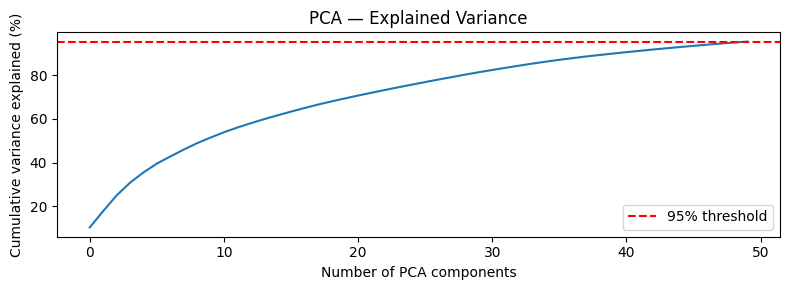


PCA Discussion:
- Reduces feature space from N → ~k components (95% variance retained).
- Removes correlated features (e.g. multiple availability / review columns).
- Training is faster, but tree-based models lose interpretability.
- Linear models benefit most from PCA; ensemble trees work well without it.
- We will compare both (raw scaled) and (PCA) feature sets below.



In [149]:
import time
from sklearn.impute import SimpleImputer

# Check for any remaining NaNs and report
nan_counts = np.isnan(X_train).sum(axis=0)
if nan_counts.sum() > 0:
    nan_cols = [(feature_cols[i], nan_counts[i]) for i in np.where(nan_counts > 0)[0]]
    print(f"NaN columns before imputation: {nan_cols[:10]}")

# Impute remaining NaNs with column median before scaling/PCA
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_val   = imputer.transform(X_val)
X_test  = imputer.transform(X_test)
X_all   = imputer.transform(X_all)
print(f"After imputation — any NaN in X_train: {np.isnan(X_train).any()}")

# Standardize (PCA is scale-sensitive)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# PCA keeping 95% of variance
pca = PCA(n_components=0.95, svd_solver='full', random_state=42)
t0 = time.time()
X_train_pca = pca.fit_transform(X_train_sc)
X_val_pca   = pca.transform(X_val_sc)
X_test_pca  = pca.transform(X_test_sc)
pca_time = time.time() - t0

n_pca = pca.n_components_
var_explained = pca.explained_variance_ratio_.cumsum()[-1]
print(f"PCA: {X_train.shape[1]} → {n_pca} components ({var_explained*100:.1f}% variance) in {pca_time:.1f}s")

# Scree plot
plt.figure(figsize=(8, 3))
plt.plot(np.cumsum(pca.explained_variance_ratio_[:min(50, len(pca.explained_variance_ratio_))]) * 100)
plt.axhline(95, color='red', linestyle='--', label='95% threshold')
plt.xlabel("Number of PCA components")
plt.ylabel("Cumulative variance explained (%)")
plt.title("PCA — Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

print("""
PCA Discussion:
- Reduces feature space from N → ~k components (95% variance retained).
- Removes correlated features (e.g. multiple availability / review columns).
- Training is faster, but tree-based models lose interpretability.
- Linear models benefit most from PCA; ensemble trees work well without it.
- We will compare both (raw scaled) and (PCA) feature sets below.
""")

## 7b. PyTorch MLP on GPU (RTX 5080)

In [150]:
import time

class PriceMLP(nn.Module):
    def __init__(self, n_in):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 512), nn.BatchNorm1d(512), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.2),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(128, 64),  nn.GELU(),
            nn.Linear(64, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

def rmse(a, b):
    return np.sqrt(mean_squared_error(a, b))

def train_mlp(X_tr, y_tr, X_v, y_v_raw,
              epochs=300, batch_size=2048, lr=3e-3, patience=20):
    n_in = X_tr.shape[1]
    net = PriceMLP(n_in).to(DEVICE)
    opt = torch.optim.AdamW(net.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit = nn.HuberLoss(delta=0.5)

    Xt = torch.tensor(X_tr, dtype=torch.float32)
    yt = torch.tensor(y_tr, dtype=torch.float32)
    Xv_gpu = torch.tensor(X_v, dtype=torch.float32).to(DEVICE)

    loader = DataLoader(TensorDataset(Xt, yt), batch_size=batch_size,
                        shuffle=True, pin_memory=torch.cuda.is_available())

    best_rmse, best_state, wait = float('inf'), None, 0
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        net.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(net(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(net.parameters(), 1.0)
            opt.step()
        sched.step()

        net.eval()
        with torch.no_grad():
            pred_log = net(Xv_gpu).cpu().numpy()
        val_r = rmse(y_v_raw, np.expm1(pred_log))

        if val_r < best_rmse:
            best_rmse = val_r
            best_state = {k: v.clone() for k, v in net.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stop epoch {epoch}  best RMSE={best_rmse:.2f}")
                break
        if epoch % 50 == 0:
            print(f"  Epoch {epoch:3d}  val RMSE={val_r:.2f}  ({time.time()-t0:.0f}s)")

    net.load_state_dict(best_state)
    return net, best_rmse

print(f"Training PyTorch MLP on {DEVICE} ...")
mlp_model, mlp_val_rmse = train_mlp(X_train_sc, y_train, X_val_sc, y_val_raw)
print(f"MLP val RMSE: {mlp_val_rmse:.2f}")

Training PyTorch MLP on cuda ...
  Epoch  50  val RMSE=389.05  (22s)
  Early stop epoch 96  best RMSE=353.78
MLP val RMSE: 353.78


## 8. Model Training & Comparison (Task 4)

In [151]:
results = {}

# ── Baselines ─────────────────────────────────────────────────────────────────
print("=== Baselines ===")
for name, model, feat in [
    ("Ridge (alpha=10)",   Ridge(alpha=10),                           "scaled"),
    ("Lasso (alpha=1e-3)", Lasso(alpha=1e-3, max_iter=5000),          "scaled"),
    ("Decision Tree",      DecisionTreeRegressor(max_depth=12, random_state=42), "raw"),
]:
    Xtr = X_train_sc if feat == "scaled" else X_train
    Xv  = X_val_sc   if feat == "scaled" else X_val
    model.fit(Xtr, y_train)
    r = rmse(y_val_raw, np.expm1(model.predict(Xv)))
    results[name] = (r, model, feat)
    print(f"  {name:<35} RMSE={r:>8.2f}")

print("\n=== Random Forest ===")
rf = RandomForestRegressor(n_estimators=500, min_samples_leaf=2, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
r = rmse(y_val_raw, np.expm1(rf.predict(X_val)))
results["Random Forest"] = (r, rf, "raw")
print(f"  {'Random Forest':<35} RMSE={r:>8.2f}")

# ── LightGBM — original best params, no sample weights ───────────────────────
if HAS_LGBM:
    print("\n=== LightGBM ===")
    lgbm_model = lgb.LGBMRegressor(
        n_estimators=3000, learning_rate=0.02, num_leaves=255,
        max_depth=-1, min_child_samples=15,
        subsample=0.8, subsample_freq=1, colsample_bytree=0.7,
        reg_alpha=0.1, reg_lambda=1.0,
        n_jobs=-1, random_state=42, verbose=-1,
        **({'device': 'gpu'} if torch.cuda.is_available() else {}),
    )
    t0 = time.time()
    lgbm_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)],
    )
    r = rmse(y_val_raw, np.expm1(lgbm_model.predict(X_val)))
    results["LightGBM"] = (r, lgbm_model, "raw")
    print(f"  {'LightGBM':<35} RMSE={r:>8.2f}  ({time.time()-t0:.1f}s)  "
          f"best_iter={lgbm_model.best_iteration_}")

# ── XGBoost — original best params, no sample weights ────────────────────────
if HAS_XGB:
    print("\n=== XGBoost ===")
    xgb_model = xgb.XGBRegressor(
        n_estimators=3000, learning_rate=0.02, max_depth=7,
        subsample=0.8, colsample_bytree=0.7,
        reg_alpha=0.1, reg_lambda=1.0,
        n_jobs=-1, random_state=42, verbosity=0,
        early_stopping_rounds=50,
        **({'device': 'cuda'} if torch.cuda.is_available() else {}),
    )
    t0 = time.time()
    xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    r = rmse(y_val_raw, np.expm1(xgb_model.predict(X_val)))
    results["XGBoost"] = (r, xgb_model, "raw")
    print(f"  {'XGBoost':<35} RMSE={r:>8.2f}  ({time.time()-t0:.1f}s)  "
          f"best_iter={xgb_model.best_iteration}")

results["PyTorch MLP"] = (mlp_val_rmse, None, "scaled")

print("\n=== All models ranked ===")
for name, (r, _, _) in sorted(results.items(), key=lambda x: x[1][0]):
    print(f"  {name:<35} {r:.2f}")

=== Baselines ===
  Ridge (alpha=10)                    RMSE=12532.76
  Lasso (alpha=1e-3)                  RMSE=14583.05
  Decision Tree                       RMSE=  483.44

=== Random Forest ===
  Random Forest                       RMSE=  386.38

=== LightGBM ===
  LightGBM                            RMSE=  339.03  (108.3s)  best_iter=2990

=== XGBoost ===
  XGBoost                             RMSE=  338.70  (11.5s)  best_iter=2997

=== All models ranked ===
  XGBoost                             338.70
  LightGBM                            339.03
  PyTorch MLP                         353.78
  Random Forest                       386.38
  Decision Tree                       483.44
  Ridge (alpha=10)                    12532.76
  Lasso (alpha=1e-3)                  14583.05


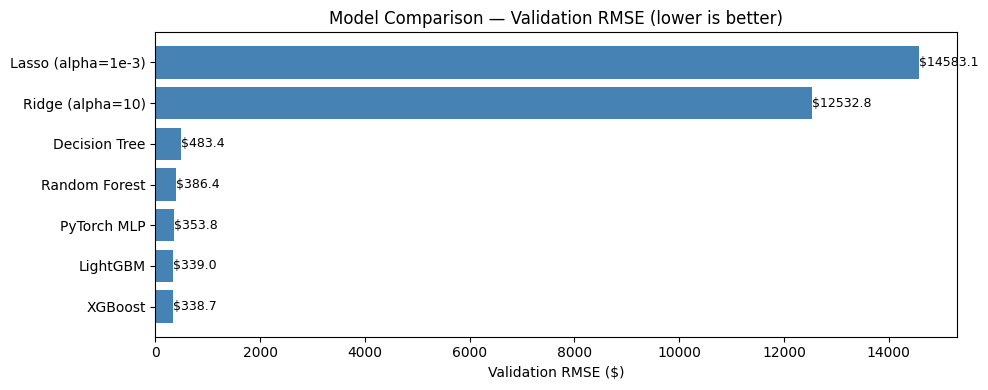


Best model: XGBoost  →  Val RMSE = $338.70


In [152]:
# --- Summary plot ---
names  = list(results.keys())
rmses  = [results[n][0] for n in names]

sorted_pairs = sorted(zip(rmses, names))
rmses_s, names_s = zip(*sorted_pairs)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(names_s, rmses_s, color='steelblue')
ax.set_xlabel("Validation RMSE ($)")
ax.set_title("Model Comparison — Validation RMSE (lower is better)")
for bar, v in zip(bars, rmses_s):
    ax.text(v + 0.5, bar.get_y() + bar.get_height()/2, f"${v:.1f}", va='center', fontsize=9)
plt.tight_layout()
plt.show()

best_name = names_s[0]
best_rmse = rmses_s[0]
print(f"\nBest model: {best_name}  →  Val RMSE = ${best_rmse:.2f}")

## 9. Feature Importance (best tree-based model)

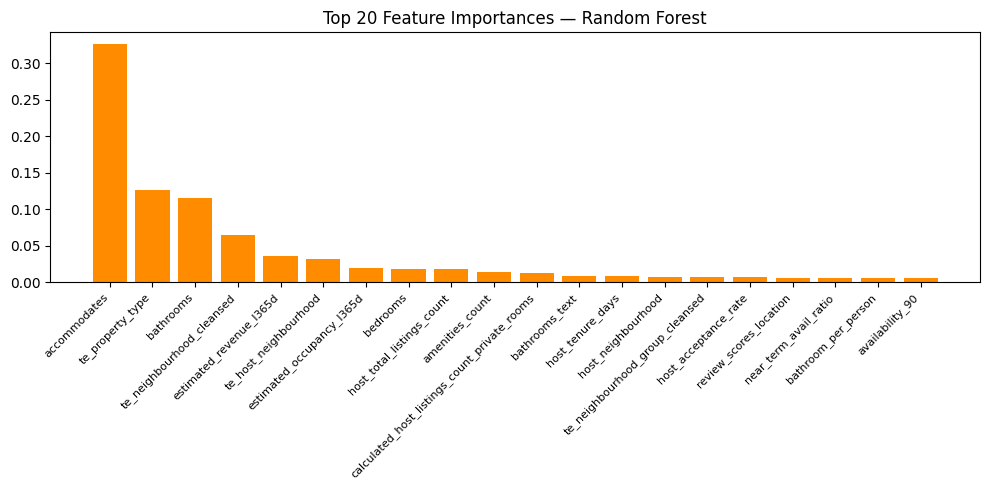

In [153]:
# Show feature importances for Gradient Boosting or Random Forest
tree_model_name = "Gradient Boosting" if "Gradient Boosting" in results else "Random Forest"
tree_model = results[tree_model_name][1]

importances = tree_model.feature_importances_
top_k = 20
idx = np.argsort(importances)[::-1][:top_k]

plt.figure(figsize=(10, 5))
plt.bar(range(top_k), importances[idx], color='darkorange')
plt.xticks(range(top_k), [feature_cols[i] for i in idx], rotation=45, ha='right', fontsize=8)
plt.title(f"Top {top_k} Feature Importances — {tree_model_name}")
plt.tight_layout()
plt.show()

## 10. Generate Test Predictions & Save

In [ ]:
X_feat_full = {"raw": X_all, "scaled": scaler.transform(X_all),
               "pca": pca.transform(scaler.transform(X_all))}
X_test_feat  = {"raw": X_test, "scaled": X_test_sc, "pca": X_test_pca}

sorted_results = sorted(results.items(), key=lambda x: x[1][0])
print("=== All models val RMSE ===")
for name, (r, _, _) in sorted_results:
    print(f"  {name:<35} {r:.2f}")

# LightGBM + XGBoost + MLP — best config (1010.07 on LB)
BLEND_MODELS = {"LightGBM", "XGBoost", "PyTorch MLP"}
BLEND_MODELS = {n for n in BLEND_MODELS if n in results}
print(f"\nBlending: {sorted(BLEND_MODELS)}")

all_preds = {}

for name, (val_r, model, feat) in sorted_results:
    if name not in BLEND_MODELS or model is None:
        continue

    Xfull = X_feat_full[feat]
    Xtest = X_test_feat[feat]

    if HAS_XGB and isinstance(model, xgb.XGBRegressor):
        best_n = model.best_iteration + 1
        refitted = xgb.XGBRegressor(
            n_estimators=best_n, learning_rate=model.learning_rate,
            max_depth=model.max_depth, subsample=model.subsample,
            colsample_bytree=model.colsample_bytree,
            reg_alpha=model.reg_alpha, reg_lambda=model.reg_lambda,
            n_jobs=-1, random_state=42, verbosity=0,
            **({'device': 'cuda'} if torch.cuda.is_available() else {}),
        )
        refitted.fit(Xfull, y_log)
        all_preds[name] = np.expm1(refitted.predict(Xtest)).clip(min=0)

    elif HAS_LGBM and isinstance(model, lgb.LGBMRegressor):
        best_n = model.best_iteration_
        refitted = lgb.LGBMRegressor(
            n_estimators=best_n, learning_rate=model.learning_rate,
            num_leaves=model.num_leaves, min_child_samples=model.min_child_samples,
            subsample=model.subsample, subsample_freq=1,
            colsample_bytree=model.colsample_bytree,
            reg_alpha=model.reg_alpha, reg_lambda=model.reg_lambda,
            n_jobs=-1, random_state=42, verbose=-1,
            **({'device': 'gpu'} if torch.cuda.is_available() else {}),
        )
        refitted.fit(Xfull, y_log)
        all_preds[name] = np.expm1(refitted.predict(Xtest)).clip(min=0)

    else:
        model.fit(Xfull, y_log)
        all_preds[name] = np.expm1(model.predict(Xtest)).clip(min=0)

    print(f"  Retrained: {name}")

# ── MLP: retrain on full data for fixed epochs ────────────────────────────────
if "PyTorch MLP" in BLEND_MODELS:
    print("\nRetraining MLP on full data...")
    mlp_epochs = 250
    X_all_sc_full = scaler.transform(X_all)
    mlp_final = PriceMLP(X_all_sc_full.shape[1]).to(DEVICE)
    opt   = torch.optim.AdamW(mlp_final.parameters(), lr=3e-3, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=mlp_epochs)
    crit  = nn.HuberLoss(delta=0.5)
    loader = DataLoader(
        TensorDataset(torch.tensor(X_all_sc_full, dtype=torch.float32),
                      torch.tensor(y_log, dtype=torch.float32)),
        batch_size=2048, shuffle=True, pin_memory=torch.cuda.is_available())
    t0 = time.time()
    for epoch in range(1, mlp_epochs + 1):
        mlp_final.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            crit(mlp_final(xb), yb).backward()
            nn.utils.clip_grad_norm_(mlp_final.parameters(), 1.0)
            opt.step()
        sched.step()
        if epoch % 50 == 0:
            print(f"  Epoch {epoch}  ({time.time()-t0:.0f}s)")
    mlp_final.eval()
    with torch.no_grad():
        mlp_test_log = mlp_final(
            torch.tensor(X_test_sc, dtype=torch.float32).to(DEVICE)
        ).cpu().numpy()
    all_preds["PyTorch MLP"] = np.expm1(mlp_test_log).clip(min=0)

# ── Inverse-RMSE² weighted blend ──────────────────────────────────────────────
rmse_vals = {name: results[name][0] for name in all_preds}
weights   = {name: 1.0 / (r ** 2) for name, r in rmse_vals.items()}
total_w   = sum(weights.values())

blend = np.zeros(len(list(all_preds.values())[0]))
print("\nFinal blend weights:")
for name, pred in all_preds.items():
    w = weights[name] / total_w
    blend += w * pred
    print(f"  {name:<35} w={w:.3f}  RMSE={rmse_vals[name]:.2f}")

print(f"\nPredictions — min={blend.min():.1f}  max={blend.max():.1f}  mean={blend.mean():.1f}")
np.savetxt("predictions.txt", blend, fmt="%.2f")
print("Saved → predictions.txt")